# Exercises for Section 2.8 Probability models for random samples

This notebook contains the exercises from [Section 2.8 Probability models for random samples](https://minireference.com/static/excerpts/noBSstats_part1_preview.pdf#page=83) of the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Figures setup
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={'figure.figsize': (5,2)},
)
%config InlineBackend.figure_format = 'retina'

In [3]:
# Simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

## Exercies

### E2.56



In [5]:
# Create the computer model `rvV`
from scipy.stats import uniform
rvV = uniform(100, 120-100)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(33)

# Generate 1000 random samples of size n=30 from rvV
vsamples = [rvV.rvs(30) for j in range(1000)]
vsamples[0:3]

[array([104.97020255, 108.99950842, 108.21881606, 105.20599382,
        117.40791377, 103.70079854, 100.39322851, 119.06504063,
        113.60901609, 109.73176253, 119.3005364 , 107.86797478,
        101.59115143, 107.02814849, 103.27270325, 119.66333642,
        117.61256368, 109.88126936, 108.01918482, 109.02582926,
        114.41753697, 104.95536569, 112.45559905, 102.84897632,
        104.02352565, 101.62435459, 119.0694459 , 101.11476539,
        111.99072967, 114.45995261]),
 array([119.40579439, 116.43138915, 110.55102135, 106.62953459,
        107.07964391, 101.58060603, 111.11828761, 103.31588926,
        105.90475662, 116.8121697 , 107.25124019, 106.81627955,
        114.20803488, 100.63415503, 109.44775732, 114.63153245,
        115.46431549, 104.82489584, 106.12394091, 102.73299277,
        111.91471439, 103.25137733, 116.04654429, 110.00253304,
        101.18988651, 107.83731552, 112.39551004, 103.76383687,
        108.5577695 , 101.77963276]),
 array([114.6526087 , 107.86

In [7]:
vbars = [np.mean(vsample) for vsample in vsamples]
vbars[0:3]

[109.38417435493896, 108.59011190939047, 111.31117404436553]

In [8]:
np.mean(vbars), np.std(vbars, ddof=1)

(109.99974398182152, 1.0604226051841408)

In [9]:
muVbar = rvV.mean()
sigmaV = rvV.std()
sigmaVbar = sigmaV / np.sqrt(30)
print("CLT prediction: Vbar ~ norm(", muVbar, ",", sigmaVbar, ")")

CLT prediction: Vbar ~ norm( 110.0 , 1.0540925533894596 )


### E2.57



In [11]:
from scipy.stats import norm
rvZ = norm(0,1)

In [12]:
# Define the function that computes the variance
def var(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

In [13]:
xs = [1,2,5]
var(xs), np.var(xs, ddof=1), pd.Series(xs).var()

(4.333333333333334, 4.333333333333334, 4.333333333333334)

In [14]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(52)

# Generate the sampling distribution of the variance
from ministats import gen_sampling_dist
zvars30 = gen_sampling_dist(rvZ, var, n=30, N=10000)
zvars30[0:5]

[0.8129460963113291,
 0.8558403023818412,
 0.7686328368120574,
 1.1419158653671484,
 0.7043972646116083]

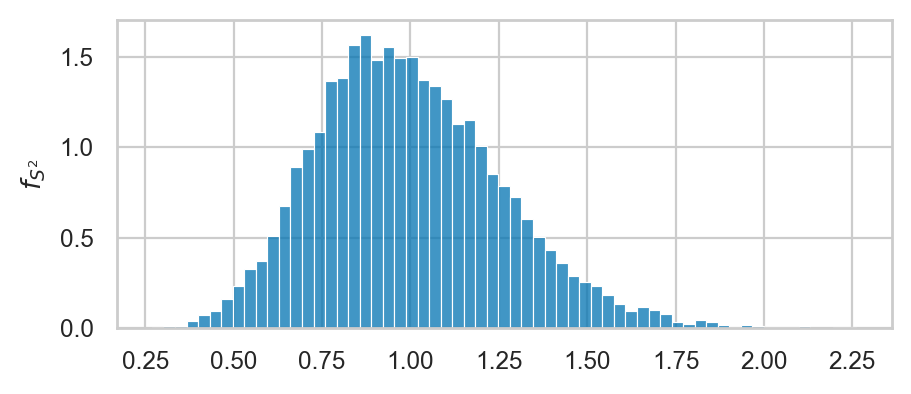

In [15]:
ax = sns.histplot(x=zvars30, stat="density");
ax.set_ylabel("$f_{S^2}$");

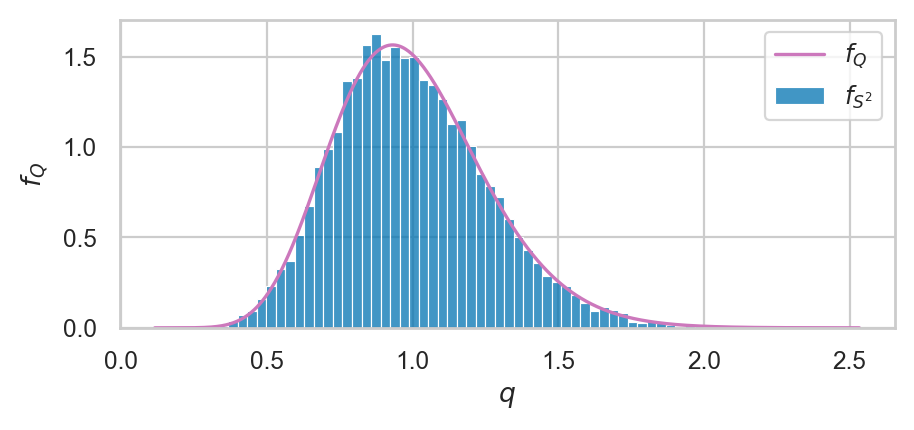

In [16]:
ax = sns.histplot(x=zvars30, label="$f_{S^2}$", stat="density")

from scipy.stats import chi2
rvQ = chi2(df=29, scale=1/29)
from ministats import plot_pdf
plot_pdf(rvQ, rv_name="Q", ax=ax, label="$f_Q$", color="C4");

### E2.58



In [18]:
from scipy.stats import norm

muE = 2
stdE = 2
stdEbar = stdE / np.sqrt(100)

muT = 100 * muE
stdT = 100 * stdEbar
print(muT, stdT)

rvT = norm(muT, stdT)
1 - rvT.cdf(240)

200 20.0


0.02275013194817921

### E2.59



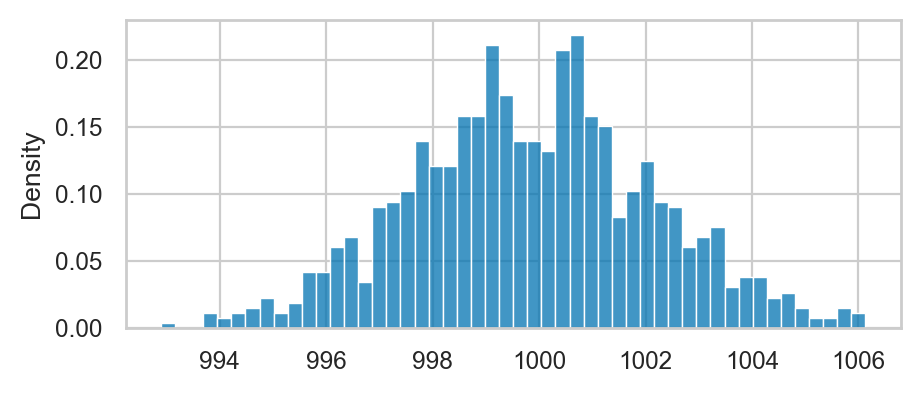

In [20]:
# a) 
import numpy as np
from scipy.stats import norm

muK, sigmaK = 1000, 10
rvK = norm(muK, sigmaK)

# Generate the sampling distribution of the standard deviation
from ministats import gen_sampling_dist
kbars = gen_sampling_dist(rvK, np.mean, n=20, N=10000)
sns.histplot(x=kbars, bins=50, stat="density");

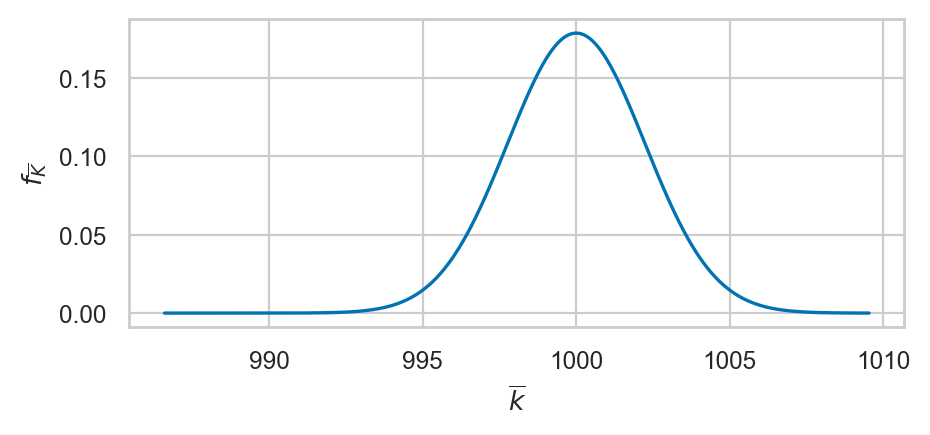

In [21]:
# b) CLT
muKbar = muK
sigmaKbar = sigmaK / np.sqrt(20)

rvKbar = norm(muKbar, sigmaKbar)

from ministats import plot_pdf
plot_pdf(rvKbar, rv_name="\\overline{K}");

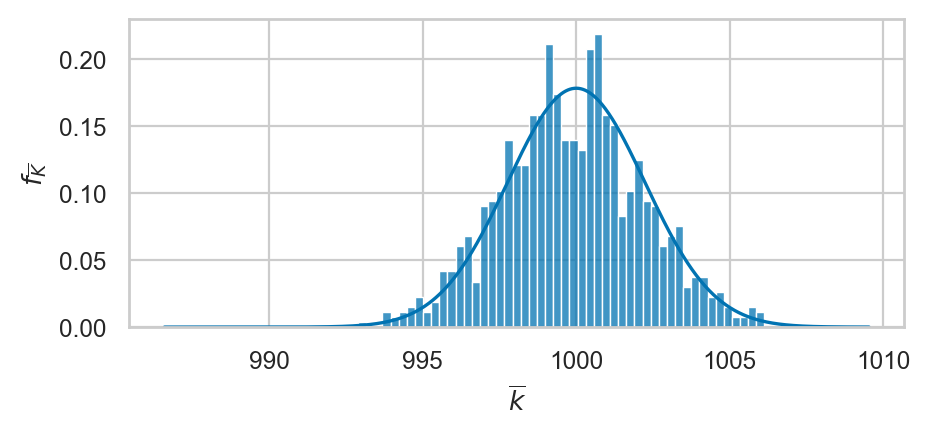

In [22]:
# c) Combine plots
ax = sns.histplot(x=kbars, bins=50, stat="density")
plot_pdf(rvKbar, rv_name="\\overline{K}", ax=ax);

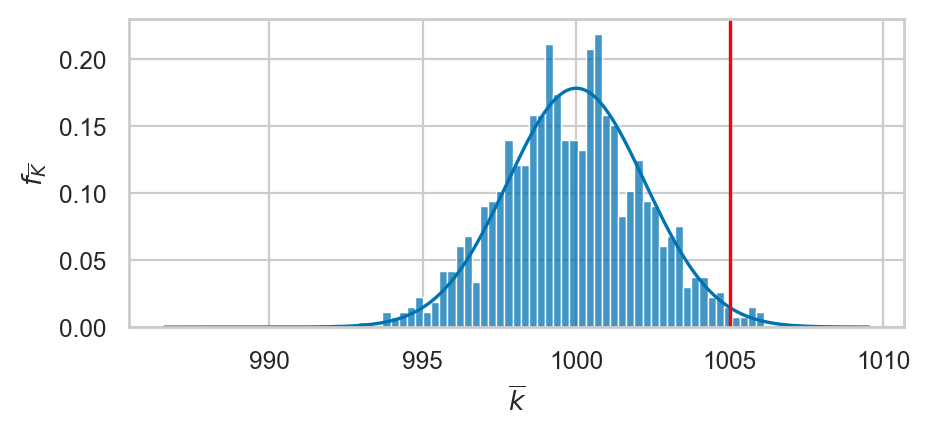

In [23]:
ax = sns.histplot(x=kbars, bins=50, stat="density")
plot_pdf(rvKbar, rv_name="\\overline{K}", ax=ax);

ax.axvline(1005, color="red");

In [24]:
len([kbar for kbar in kbars if kbar >= 1005]) / len(kbars)

0.011

In [31]:
len([kbar for kbar in kbars if kbar >= 1005]) / len(kbars)

0.011

In [26]:
1 - rvKbar.cdf(1005)

0.0126736593387341

### E2.60



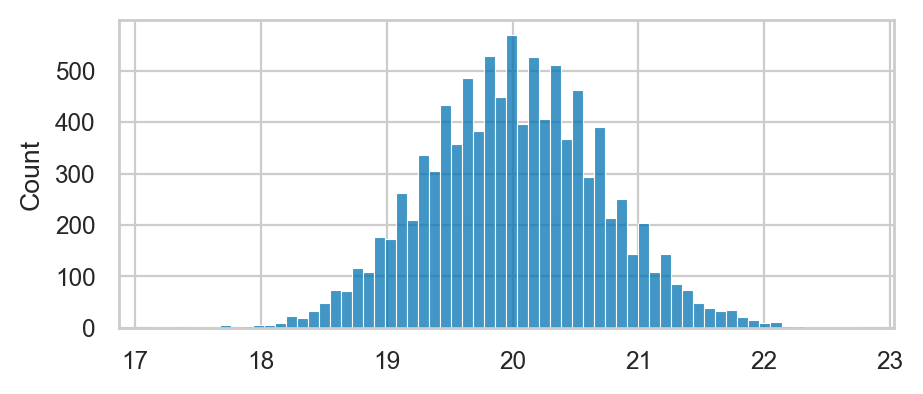

In [35]:
from scipy.stats import poisson
rvH = poisson(20)

hbars40 = gen_sampling_dist(rvH, np.mean, n=40)
sns.histplot(x=hbars40);

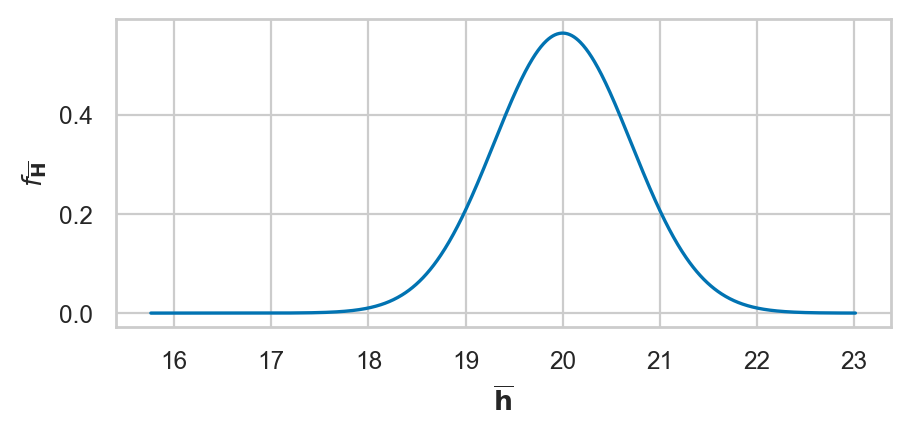

In [52]:
muH = rvH.mean()
sigmaH = rvH.std()

muHbar = muH
sigmaHbar = sigmaH / np.sqrt(40)
rvHbar = norm(muHbar, sigmaHbar)

plot_pdf(rvHbar, rv_name=r"\overline{\mathbf{H}}");

### E2.61



In [43]:
from scipy.stats import binom
rvX = binom(n=100, p=0.3)

sum([rvX.pmf(x) for x in range(25,35+1)])

0.7703512122767611

In [57]:
p = 0.3
n = 100

muA = p
sigmaA = np.sqrt(p * (1-p))
muA, sigmaA

(0.3, 0.458257569495584)

In [56]:
muAbar = p
sigmaAbar = sigmaA / np.sqrt(n) # = np.sqrt(p*(1-p)/n)
muAbar, sigmaAbar

(0.3, 0.0458257569495584)

In [55]:
muN_X = n * muAbar
sigmaN_X = n * sigmaAbar
print("N ~ norm(", muN_X, ",", sigmaN_X, ")")
rvN_X = norm(muN_X, sigmaN_X)

from scipy.integrate import quad
quad(rvN_X.pdf, a=24.5, b=35.5)[0]

N ~ norm( 30.0 , 4.58257569495584 )


0.7699377019736036